# 02 · Location features from OpenStreetMap

## The question

We already know each listing's **borough**. But "Camden" covers a flat right on top
of Camden Town station *and* a house 25 minutes' walk from any train. In London that
difference is worth real money. So: **does knowing the precise spot — not just the
borough — help predict price?**

The plan: build a few numbers that describe a location, add them to a simple model,
and check whether the model actually gets better. If it doesn't, the borough label
was already capturing "location" and we keep things simple.

### The features we build

| Feature | Plain meaning | Why it might move price |
|---|---|---|
| `dist_station_m` | metres to nearest rail/Tube/DLR station | guests travel by Tube; a short walk to one is a real selling point |
| `stations_within_1km` | how many stations are close | more stations = more places reachable easily |
| `dist_center_m` | metres to Charing Cross (London's traditional centre) | blunt proxy for "central / touristy" |
| `dist_restaurant_m`, `food_within_500m` | nearest, and count within 500 m, of restaurants/cafés/pubs/bars | a lively street is worth more to a visitor |
| `dist_park_m` | metres to nearest green space (0 if inside one) | some guests pay for being near a park |

We deliberately **skip schools and GP surgeries**. For a year-long tenancy they
matter; for a 4-night stay they don't, so including them would add noise. Matching
the feature set to the actual use-case is part of the work.

> 📚 **Where the "add features, then run an ablation" idea comes from.** An
> *ablation* — remove/add one component and measure the change — is bog-standard
> experimental method in ML papers. Géron's *Hands-On ML* frames feature work
> exactly this way: engineer, cross-validate, keep what pays. Applied here: identical
> model, identical CV folds, the **only** difference is whether the six features are
> present.

## The one concept to get first: coordinate reference systems (CRS)

A latitude/longitude pair is an **angle** on a globe, in degrees. You cannot do
ordinary flat geometry on angles: near London, 1° of longitude is ≈ 43 km along the
ground, but 1° of latitude is ≈ 111 km. Same number of degrees, different real
distance — so Pythagoras straight on lat/long gives nonsense.

The fix is to **project** the coordinates onto a flat grid whose units are metres.
The UK's standard grid is the **British National Grid** (`EPSG:27700`). Over an area
the size of London, straight-line distance on that grid is accurate to well under
1% — plenty here. So the pattern in `londonrent.geo` is always:

    load as EPSG:4326 (lat/long)  ->  .to_crs(27700)  ->  measure in metres

> 📚 *Where this comes from:* CRS/projection basics are core GIS material — the
> geopandas "Projections" user-guide page is the practical reference, and Ordnance
> Survey documentation is why `EPSG:27700` specifically is the right grid for Great
> Britain. An **EPSG code** is just a standard ID number for a given
> coordinate system (EPSG = the former European Petroleum Survey Group registry).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from londonrent.data import build_interim
from londonrent.geo import fetch_pois, add_location_features, LOCATION_FEATURES

df = build_interim()
# same scope as notebook 01
df = df[df["price"].between(10, 1000) & df["room_type"].isin(
    ["Entire home/apt", "Private room"])].copy()
df["log_price"] = np.log(df["price"])
print(f"{len(df):,} listings in scope")

60,648 listings in scope


## 1 · The raw ingredients: OpenStreetMap points of interest

In [2]:
# Downloaded once from OpenStreetMap's Overpass API and cached in data/external
# (committed to the repo, ODbL licence). See src/londonrent/geo.py::fetch_pois.
pois = fetch_pois()
for name, gdf in pois.items():
    print(f"{name:10s} {len(gdf):>7,} features")

stations       708 features
parks       33,230 features
food        28,753 features


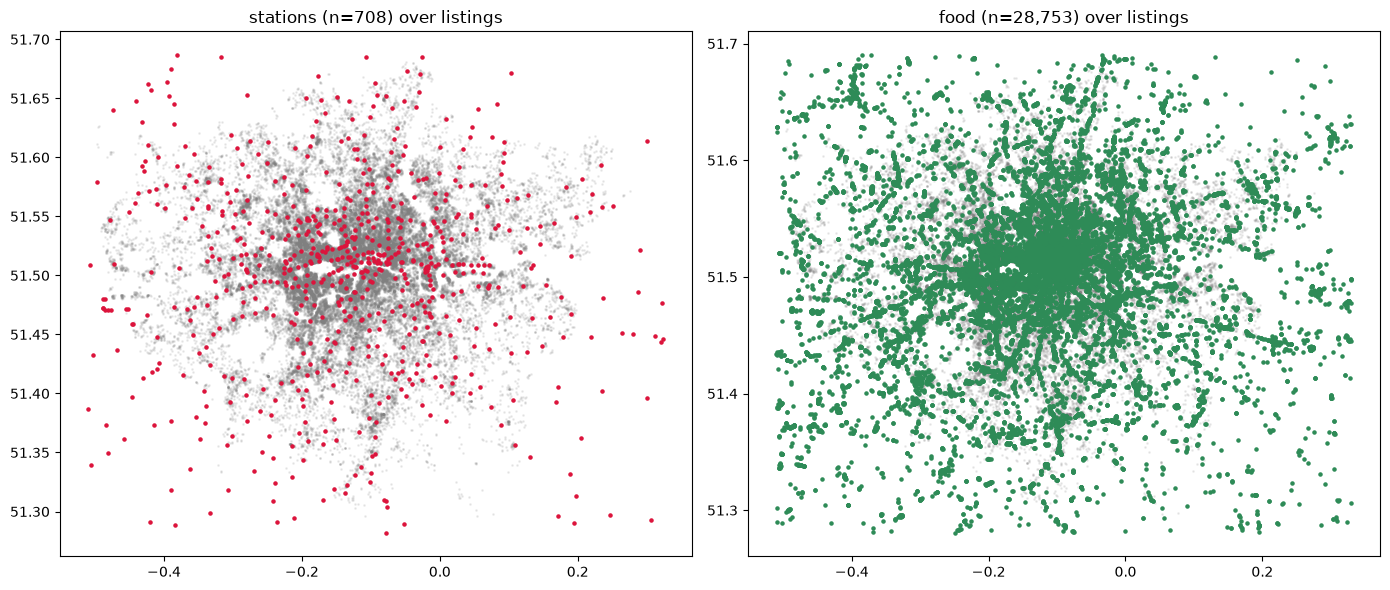

In [3]:
# Eyeball check: stations should trace the rail network, food should crowd the centre.
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, key, colour in zip(ax, ["stations", "food"], ["crimson", "seagreen"]):
    a.scatter(df["longitude"], df["latitude"], s=1, alpha=.12, color="grey")
    pts = pois[key].to_crs(4326).representative_point()
    a.scatter(pts.x, pts.y, s=5, color=colour)
    a.set_title(f"{key} (n={len(pois[key]):,}) over listings")
plt.tight_layout()

**What we see.** The station points draw out the familiar rail spider-web; food
venues pile up in the West End / City and thin out towards the edges. Both match
reality, so the OSM pull looks sound.

## 2 · Build the features and look at them

In [4]:
df = add_location_features(df, pois)
df[LOCATION_FEATURES].describe(percentiles=[.1, .5, .9]).round(0)

,dist_station_m,stations_within_1km,dist_restaurant_m,food_within_500m,dist_park_m,dist_center_m
count,60648.0,60648.0,60648.0,60648.0,60648.0,60648.0
mean,490.0,4.0,144.0,72.0,192.0,7744.0
std,371.0,3.0,144.0,117.0,153.0,5098.0
min,2.0,0.0,0.0,0.0,0.0,11.0
10%,149.0,1.0,19.0,3.0,46.0,2413.0
50%,404.0,3.0,99.0,38.0,152.0,6314.0
90%,933.0,9.0,333.0,157.0,392.0,15244.0
max,7380.0,17.0,1579.0,921.0,2352.0,28856.0


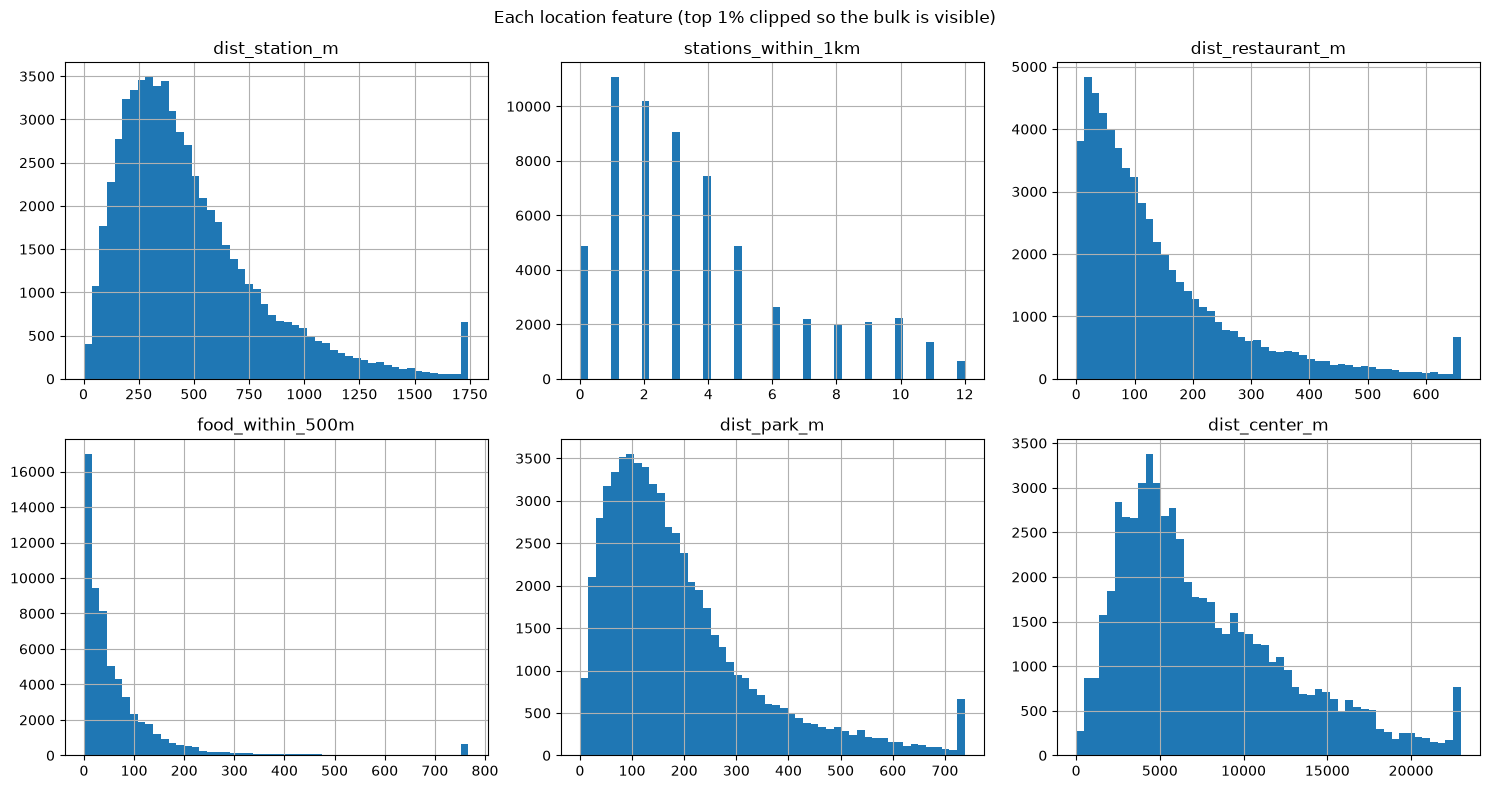

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), LOCATION_FEATURES):
    df[col].clip(upper=df[col].quantile(.99)).hist(bins=50, ax=ax)
    ax.set_title(col)
fig.suptitle("Each location feature (top 1% clipped so the bulk is visible)")
plt.tight_layout()

**What we see.** Half the listings are within ~400 m of a station (a 5-minute
walk) and within ~100 m of somewhere to eat — central London is dense. `dist_park_m`
is small almost everywhere (London has a lot of green space). `dist_center_m` runs
from a few hundred metres to ~29 km, so it spreads listings out along the
centre→edge axis nicely.

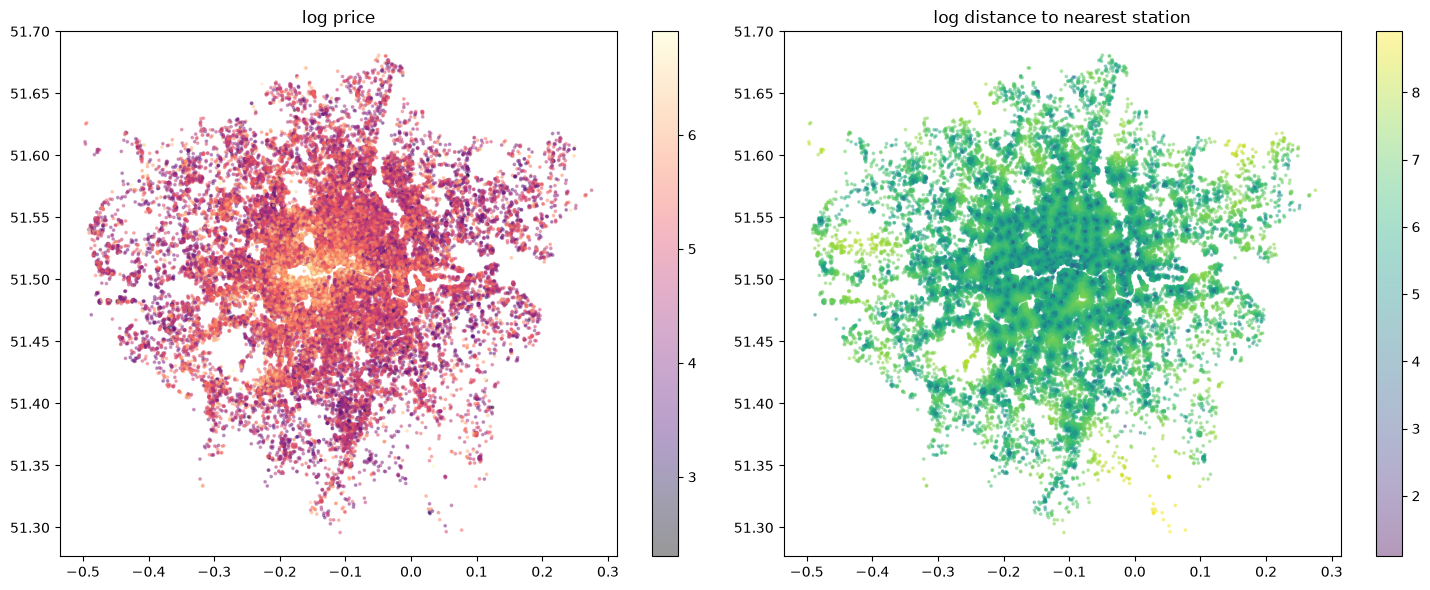

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
s0 = ax[0].scatter(df["longitude"], df["latitude"], c=df["log_price"], s=3, alpha=.4, cmap="magma")
ax[0].set_title("log price"); fig.colorbar(s0, ax=ax[0])
s1 = ax[1].scatter(df["longitude"], df["latitude"], c=np.log1p(df["dist_station_m"]),
                   s=3, alpha=.4, cmap="viridis")
ax[1].set_title("log distance to nearest station"); fig.colorbar(s1, ax=ax[1])
plt.tight_layout()

### How to read the correlation table below

**Correlation** is one number between −1 and +1 for the *straight-line* strength of
a relationship: 0 = none, +1/−1 = perfectly linear. We expect **negative** signs on
the distance features (further away → cheaper) and **positive** on the counts (more
stuff nearby → dearer). It only catches straight-line links — the model later can
use curved ones — but it's a fast check that the features point the way intuition
says.

In [7]:
corr = df[LOCATION_FEATURES + ["log_price"]].corr(numeric_only=True)["log_price"].drop("log_price")
corr.sort_values().to_frame("corr with log_price").round(3)

,corr with log_price
dist_center_m,-0.364
dist_restaurant_m,-0.244
dist_station_m,-0.208
dist_park_m,-0.182
food_within_500m,0.269
stations_within_1km,0.309


**What we see.** Every sign is what intuition predicts: `dist_center_m` (−0.36),
`dist_restaurant_m` (−0.24), `dist_station_m` (−0.21), `dist_park_m` (−0.18) all
negative; `stations_within_1km` (+0.31) and `food_within_500m` (+0.27) positive.
Distance-to-centre is the single strongest location signal.

**Insight.** None of these are huge on their own (all |r| < 0.4), which is expected:
price is multi-causal and these features are correlated *with each other* (near the
centre ⇒ near a station ⇒ near food). Correlated predictors don't add up
independently — the ablation in §3 measures their **combined** contribution, which
is the number that actually matters.
> 📚 *Where this comes from:* the "correlated predictors share variance, so don't
> sum their individual effects" point is ISLR §3.3.3 (collinearity).

## 3 · The actual test: does location *beyond the borough* help?

A controlled experiment:

* **Same model** both runs: a **gradient-boosted tree**
  (`HistGradientBoostingRegressor`). *Plain version:* it builds hundreds of tiny
  decision trees one after another, each one trained to fix the leftover mistakes of
  all the trees so far; predictions are the sum. *Practitioner version:* stagewise
  additive modelling with shrinkage, histogram-binned splits for speed.
* **Same cross-validation** both runs. *Cross-validation (CV):* chop the data into
  5 parts, train on 4, score on the held-out 1, rotate through all 5, average. It
  estimates performance on unseen listings without touching a final test set.
* **Only the feature list changes:**
  * *baseline*: borough + room type + size (`accommodates`, `bedrooms`, `bathrooms`)
  * *+ location*: the same, plus the six OpenStreetMap features.

If the features earn their place, £-error falls and R² rises.

> 📚 **Where these tools come from.** Gradient boosting: Friedman (2001), "Greedy
> Function Approximation"; I learned the mechanics from the StatQuest "Gradient
> Boost" video series and scikit-learn's ensemble user guide. The histogram-binned
> variant is LightGBM's contribution (Ke et al., 2017), which scikit-learn adopted
> as `HistGradientBoosting*`. Cross-validation: ISLR Ch. 5. One-hot encoding of the
> categoricals (below): ISLR §3.3.1 "dummy variables" / Géron Ch. 2.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

model = df.dropna(subset=["accommodates", "bedrooms", "bathrooms"]).copy()
y = model["log_price"].to_numpy()

cat = ["neighbourhood_cleansed", "room_type"]
size = ["accommodates", "bedrooms", "bathrooms"]

# One-hot encoding = turn each text label (e.g. a borough) into its own 0/1 column,
# because the model needs numbers. sparse_output=False returns a plain dense array,
# which HistGradientBoostingRegressor requires.
def cv_scores(feature_cols):
    prep = ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)],
        remainder="passthrough",
    )
    pipe = Pipeline([("prep", prep), ("gbr", HistGradientBoostingRegressor(random_state=0))])
    folds = KFold(n_splits=5, shuffle=True, random_state=0)
    pred_log = cross_val_predict(pipe, model[feature_cols], y, cv=folds)
    return {
        "R2 (log)": r2_score(y, pred_log),
        "MAE (log)": mean_absolute_error(y, pred_log),
        "MAE (GBP)": mean_absolute_error(np.exp(y), np.exp(pred_log)),
    }

results = {
    "baseline: borough + room + size": cv_scores(cat + size),
    "+ location features":             cv_scores(cat + size + LOCATION_FEATURES),
}
pd.DataFrame(results).T.round(3)

,R2 (log),MAE (log),MAE (GBP)
baseline: borough + room + size,0.603,0.317,78.320
+ location features,0.644,0.297,72.936


### Results

| Model | R² (log) | MAE (£/night) |
|---|---|---|
| baseline: borough + room type + size | 0.603 | 78.3 |
| **+ 6 location features** | **0.644** | **72.9** |

**In plain terms.** Adding "how far to the Tube / a park / the buzz / the centre"
cut the typical miss by about **£5.40 a night (≈7% smaller)** and pushed R² from
0.60 to 0.64. Not dramatic, but consistent, and it lines up with the correlation
signs. **Decision: keep all six features.** They're cheap, interpretable, and the
OSM data is committed so anyone can reproduce it.

**Insight.** The gain is modest precisely *because* the borough dummy already
absorbs most of the coarse geography — the six features are adding the
*within-borough* signal, which is a smaller slice. A £5/night structural
improvement on top of a strong baseline is a solid result for six columns; we'll
see in notebook 03 (SHAP) *how* the model spends them.

## Honest limitations

* **Parks are measured to their centre, not their nearest edge.** A listing beside a
  huge park can still show a big `dist_park_m`. A better version measures distance to
  the park polygon. Noted for a later fix.
* **`dist_center_m` is one point.** London has several centres (City, West End,
  Canary Wharf); a single Charing Cross distance flattens that.
* **OpenStreetMap is crowd-sourced.** Coverage is excellent centrally but thins at
  the edges, so outer-borough counts may be slight undercounts.
* **Spatial autocorrelation.** Nearby listings resemble each other, so a listing in
  a random CV fold often has a near-twin in the training folds — which makes plain
  `KFold` scores a little optimistic. Notebook 03 looks at grouped / spatial folds
  for the honest number.
  > 📚 *Where this comes from:* Roberts et al. (2017), "Cross-validation strategies
  > for data with spatial, temporal, hierarchical, or phylogenetic structure"
  > (*Ecography*) — the standard cite for "random CV leaks through spatial
  > autocorrelation; block/group your folds".

### Week-2 exit checklist
- [x] Location features built and cached (`data/external/osm_*.gpkg`, committed)
- [x] All correlation signs match intuition (distances −, counts +)
- [x] Ablation run: +0.04 R², −£5.4 MAE over the borough+size baseline
- [x] Decision recorded: keep all six
- [x] Limitations written down (park centroids, single centre, OSM coverage, spatial CV)